# DLR-D-Flow: Hutchinson trace-baseline variant

Demonstrates the scalar-baseline dynamic low-rank sensitivity approximation on the smallest pretrained flow-matching model (64×64, single circle, `circles-64/n1`).

A pretrained flow defines $\dot x_t=v_\theta(t,x_t)$, $x_0=z$, generated image $x_1(z)$. For the inverse problem we observe $y=\mathcal A(x_\star)$ and solve $\min_z \frac{1}{2}\lVert \mathcal A(x_1(z))-y\rVert^2$.

The exact source gradient is $\nabla_z\Phi=J_1^\top g_x$, where $J_t$ satisfies $\dot J_t=A_tJ_t$, $J_0=I$, $A_t=\partial_xv_\theta(t,x_t)$, $g_x=D\mathcal A(x_1)^\ast(\mathcal A(x_1)-y)$.

Instead of forming $J_t$ or back-propagating through the ODE solve, we track $J_t\approx \alpha_tI+U_tS_tV_t^\top$ via a Lubich-Oseledets projector-splitting integrator with skinny JVP/VJP products, giving $\widehat{\nabla_z\Phi}=\alpha_1g_x+V_1S_1^\top U_1^\top g_x$.

Uses the stable fallback (§11): after each source update, reset the residual core near zero and re-evolve from $t=0$ along the new trajectory. This copy restores the notes' trace-based scalar baseline, $d(\log\alpha_t)/dt\approx\operatorname{tr}(A_t)/d$, instead of forcing $\alpha_1=0$.

In [12]:
import os, sys
from pathlib import Path

cwd = Path.cwd()
ROOT = cwd if (cwd / "models").exists() else cwd.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import torch
import matplotlib.pyplot as plt
import cmocean
%matplotlib inline

import dlr_dflow.dlr_dflow as dd

DENSE = cmocean.cm.dense_r
BALANCE = cmocean.cm.balance

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)

# ── configurable parameters ──────────────────────────────────────────────
RESOLUTION   = 64
N_CIRCLES    = 1
EPOCH        = 50
TEST_INDEX   = 1
BLUR_SIGMA   = 5.0
N_STEPS      = 15          # flow integration steps
RANKS        = [2, 4, 8, 16]  # diagnostic ranks
RESIDUAL_EPS = 1e-4        # near-zero initial residual core
TRACE_PROBES = 8           # Hutchinson probes per flow step
# inverse problem solver
RANK         = 10
OUTER_STEPS  = 50
LR           = 0.1
# ─────────────────────────────────────────────────────────────────────────

print("device:", device, "| repo root:", ROOT)

device: cuda | repo root: /home/samzheng/d-flow


## Trace-based scalar baseline

This copied notebook locally restores the baseline from the notes:

$$\frac{d}{dt}\log\alpha_t\approx\frac{1}{d}\operatorname{tr}(A_t),\qquad \alpha_0=1.$$

The trace is estimated with fixed Gaussian Hutchinson probes. Unlike the terminal-decay schedule in the source notebook, this construction does not impose $\alpha_1=0$; the full-rank scalar component remains available at the endpoint.


In [13]:
import math

def evolve_sensitivity_trace(
    model, z, n_steps, rank, eps=1e-4, seed=0, seed_dir=None,
    scalar_baseline=True, n_probe=8,
):
    """Evolve J_t ~= alpha_t I + U_t S_t V_t^T using the notes' trace baseline."""
    height, width = z.shape[-2:]
    d = height * width
    dt = 1.0 / n_steps
    x = z
    U, S, V = dd.init_residual_factors(
        d, rank, z.device, z.dtype, eps=eps, seed=seed, seed_dir=seed_dir)
    log_alpha = 0.0
    probe_rng = torch.Generator(device=z.device).manual_seed(seed + 1)

    for i in range(n_steps):
        t = i * dt
        A, AT = dd.make_A_products(model, t, x)
        if scalar_baseline:
            probes = torch.randn(
                d, n_probe, generator=probe_rng, device=z.device, dtype=z.dtype)
            trace_estimate = (probes * A(probes)).sum().item() / n_probe
            alpha = math.exp(log_alpha)
            alpha_dot = alpha * trace_estimate / d
            log_alpha += dt * trace_estimate / d
        else:
            alpha, alpha_dot = 1.0, 0.0

        U, S, V = dd.projector_split_step(
            A, AT, U, S, V, dt, alpha, alpha_dot)
        x = x + dt * dd.velocity(model, t, x)

    alpha1 = math.exp(log_alpha) if scalar_baseline else 1.0
    return x, (U, S, V), alpha1


# action_error resolves evolve_sensitivity from the dd module at call time, so
# this assignment applies the trace baseline to both diagnostics and inversion.
dd.evolve_sensitivity = evolve_sensitivity_trace


## 1. Load the flow model and build the Gaussian-blur forward operator

In [14]:
model, res = dd.load_flow_model(resolution=RESOLUTION, n_circles=N_CIRCLES, epoch=EPOCH, device=device)
A_op = dd.make_blur(BLUR_SIGMA, device)
n_params = sum(p.numel() for p in model.parameters())
print(f"loaded {RESOLUTION}x{RESOLUTION} n{N_CIRCLES} flow model: {n_params:,} params")

loaded 64x64 n1 flow model: 2,705,517 params


## 2. A 64×64 n1 sample and its blurred observation

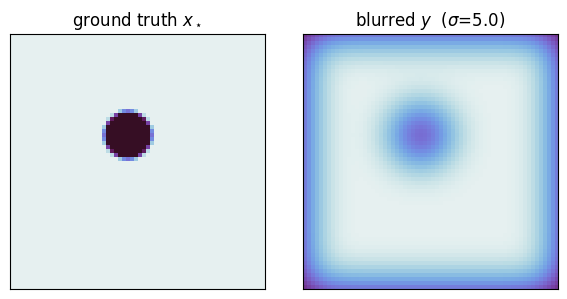

In [15]:
test = torch.load(f"data/circles-{res}-n{N_CIRCLES}.pt", map_location="cpu", weights_only=True)["test"]
x_star = test[TEST_INDEX].unsqueeze(0).to(device)
with torch.no_grad():
    y_obs = A_op(x_star)

to_np = lambda t: t.detach().squeeze().float().cpu().numpy()
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(to_np(x_star), cmap=DENSE, vmin=0, vmax=1); ax[0].set_title(r"ground truth $x_\star$")
ax[1].imshow(to_np(y_obs), cmap=DENSE, vmin=0, vmax=1); ax[1].set_title(rf"blurred $y$  ($\sigma$={BLUR_SIGMA})")
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

## 3. Jacobian-of-velocity products $A_t Q$ and $A_t^\top Q$

The method needs only the action of $A_t = \partial_x v_\theta(t,x_t)$ on a few columns. A batched JVP returns $A_t Q$ in one call (and $A_t^\top Q$ via VJP). The self-test checks these against autograd and verifies the adjoint identity.

In [16]:
dd.selftest_jacobian_products(model, device)

[selftest] JVP vs autograd rel.err = 2.41e-05
[selftest] <Aq,w> = 22.252869  vs  <q,A^T w> = 22.250053  (rel 1.27e-04)


## 4. Evolving the sensitivity: projector-splitting step

`evolve_sensitivity_trace` advances $x_t$ and factors $U_t,S_t,V_t$ together.
Each step applies one K/S/L projector-splitting update with scalar baseline
$B_t=\alpha_tI$. The baseline follows
$d(\log\alpha_t)/dt\approx\operatorname{tr}(A_t)/d$, estimated with
Hutchinson probes. The residual starts from $S_0=\varepsilon I$ with
$\varepsilon=10^{-4}$, so $\widehat J_0\approx I$.


## 5. Diagnostic: does the low-rank gradient match the exact one?

Relative action error vs autograd through the same discrete Euler flow: $\lVert J_1^\top g_x-(\alpha_1g_x+VS^\top U^\top g_x)\rVert / \lVert J_1^\top g_x\rVert$. Compares identity baseline, scalar baseline, and scalar + rank-$r$ residual. The factor basis is seeded with the endpoint-gradient direction.

In [17]:
z0 = torch.randn(1, 1, res, res, device=device,
                 generator=torch.Generator(device=device).manual_seed(0))
err_id, err_scalar, alpha1, rows, denom = dd.action_error(
    model, z0, N_STEPS, RANKS, A_op, y_obs, seed=0)

print(f"||J_1^T g_x|| = {denom:.4e}   scalar baseline alpha_1 = {alpha1:.4f}\n")
print(f"{'model':28s} {'rel.err':>9s} {'cosine':>8s}")
print(f"{'identity baseline (a=1)':28s} {err_id:9.3f} {'-':>8s}")
print(f"{'scalar baseline (a1 I)':28s} {err_scalar:9.3f} {'-':>8s}")
for r, rel, cos in rows:
    print(f"{'scalar + rank ' + str(r):28s} {rel:9.3f} {cos:8.3f}")

||J_1^T g_x|| = 2.9897e-01   scalar baseline alpha_1 = 0.0351

model                          rel.err   cosine
identity baseline (a=1)         18.683        -
scalar baseline (a1 I)           0.924        -
scalar + rank 2                  0.626    0.811
scalar + rank 4                  0.632    0.814
scalar + rank 8                  0.641    0.815
scalar + rank 16                 0.652    0.811


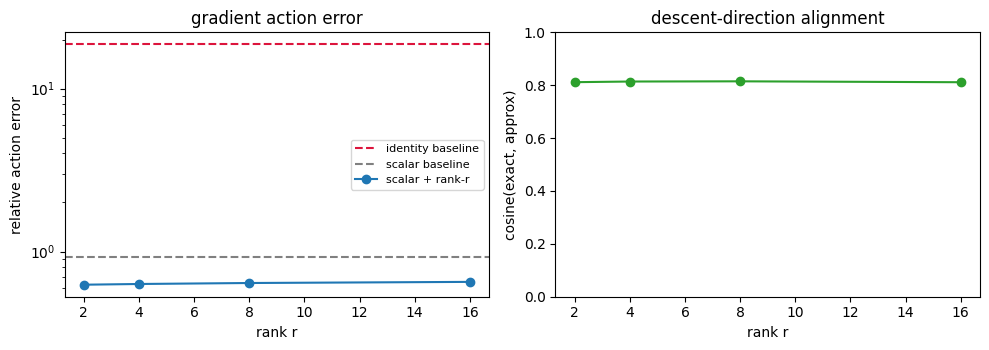

In [18]:
rank_vals = [r for r, _, _ in rows]
rel_vals = [rel for _, rel, _ in rows]
cos_vals = [c for _, _, c in rows]

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].axhline(err_id, ls="--", color="crimson", label="identity baseline")
ax[0].axhline(err_scalar, ls="--", color="gray", label="scalar baseline")
ax[0].plot(rank_vals, rel_vals, "o-", color="C0", label="scalar + rank-r")
ax[0].set_yscale("log"); ax[0].set_xlabel("rank r"); ax[0].set_ylabel("relative action error")
ax[0].set_title("gradient action error"); ax[0].legend(fontsize=8)

ax[1].plot(rank_vals, cos_vals, "o-", color="C2")
ax[1].set_xlabel("rank r"); ax[1].set_ylabel("cosine(exact, approx)")
ax[1].set_title("descent-direction alignment"); ax[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()

## 6. Solving the inverse problem with the DLR-D-Flow gradient

At each outer iteration: (1) reset $S_0=\varepsilon I$, seed with previous source gradient; (2) integrate flow and factors from $t=0$ to $t=1$; (3) form $\widehat{\nabla_z\Phi}=\alpha_1g_x+VS^\top U^\top g_x$; (4) Adam update, retain best measurement MSE.

In [ ]:
z = z0.clone()
m = torch.zeros_like(z)
v = torch.zeros_like(z)
b1, b2, adam_eps = 0.9, 0.999, 1e-8
misfits = []
best_misfit, best_z, best_step = float("inf"), z.clone(), 0
seed_dir = None

for step in range(1, OUTER_STEPS + 1):
    x1, factors, alpha1 = dd.evolve_sensitivity(
        model, z, N_STEPS, rank=RANK, seed=0, seed_dir=seed_dir,
        eps=RESIDUAL_EPS, n_probe=TRACE_PROBES)
    g_x = dd.terminal_gradient(x1, A_op, y_obs)
    gz = dd.approx_source_gradient(factors, g_x, alpha1)

    with torch.no_grad():
        misfit = (A_op(x1) - y_obs).pow(2).mean().item()
    misfits.append(misfit)
    is_new_best = misfit < best_misfit
    if is_new_best:
        best_misfit, best_z, best_step = misfit, z.detach().clone(), step

    seed_dir = gz.detach().reshape(-1, 1)
    seed_dir = seed_dir / (seed_dir.norm() + 1e-12)

    m = b1 * m + (1 - b1) * gz
    v = b2 * v + (1 - b2) * gz.square()
    m_hat = m / (1 - b1 ** step)
    v_hat = v / (1 - b2 ** step)
    z = z - LR * m_hat / (v_hat.sqrt() + adam_eps)

    if step % 5 == 0 or step == 1:
        print(f"step {step:3d}: data-misfit MSE = {misfit:.3e}"
              + (f"  |  NEW BEST = {best_misfit:.3e} at step {best_step}" if is_new_best else f"  |  best so far = {best_misfit:.3e} at step {best_step}"))
    elif is_new_best:
        print(f"step {step:3d}: data-misfit MSE = {misfit:.3e}  |  NEW BEST = {best_misfit:.3e} at step {best_step}")

with torch.no_grad():
    x_hat_raw = dd.euler_flow(model, best_z, N_STEPS)
    x_hat = x_hat_raw.clamp(0, 1)
raw_img_mse = (x_hat_raw - x_star).pow(2).mean().item()
clamped_img_mse = (x_hat - x_star).pow(2).mean().item()
print(f"\nbest data-misfit MSE = {best_misfit:.3e} at step {best_step}")
print(f"raw image MSE vs ground truth = {raw_img_mse:.3e}")
print(f"clamped image MSE vs ground truth = {clamped_img_mse:.3e}")

step   1: data-misfit MSE = 1.443e-02  |  NEW BEST = 1.443e-02 at step 1
step   2: data-misfit MSE = 1.402e-02  |  NEW BEST = 1.402e-02 at step 2
step   3: data-misfit MSE = 8.594e-03  |  NEW BEST = 8.594e-03 at step 3
step   4: data-misfit MSE = 8.305e-03  |  NEW BEST = 8.305e-03 at step 4
step   5: data-misfit MSE = 3.599e-03  |  NEW BEST = 3.599e-03 at step 5
step   6: data-misfit MSE = 3.341e-03  |  NEW BEST = 3.341e-03 at step 6
step   7: data-misfit MSE = 3.310e-03  |  NEW BEST = 3.310e-03 at step 7
step  10: data-misfit MSE = 3.104e-03  |  NEW BEST = 3.104e-03 at step 10
step  13: data-misfit MSE = 2.921e-03  |  NEW BEST = 2.921e-03 at step 13
step  14: data-misfit MSE = 1.654e-03  |  NEW BEST = 1.654e-03 at step 14
step  15: data-misfit MSE = 9.685e-03  |  best so far = 1.654e-03 at step 14
step  17: data-misfit MSE = 1.442e-03  |  NEW BEST = 1.442e-03 at step 17
step  20: data-misfit MSE = 2.583e-02  |  best so far = 1.442e-03 at step 17
step  25: data-misfit MSE = 2.596e-02  

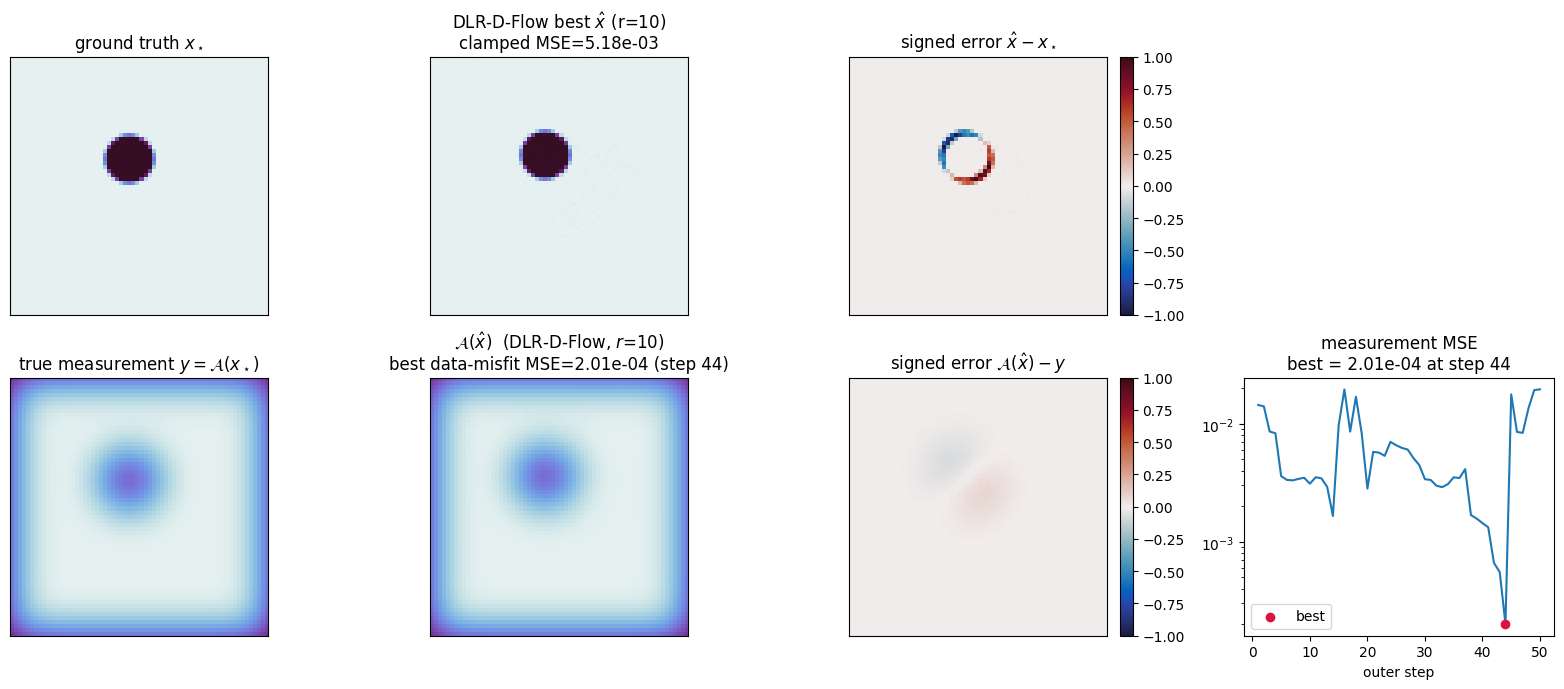

In [ ]:
signed_err = to_np(x_hat) - to_np(x_star)

with torch.no_grad():
    y_hat = A_op(x_hat)
signed_err_meas = to_np(y_hat) - to_np(y_obs)

fig, ax = plt.subplots(2, 4, figsize=(16, 7))
ax = ax.ravel()

ax[0].imshow(to_np(x_star), cmap=DENSE, vmin=0, vmax=1)
ax[0].set_title(r"ground truth $x_\star$")
ax[1].imshow(to_np(x_hat), cmap=DENSE, vmin=0, vmax=1)
ax[1].set_title(
    f"DLR-D-Flow best $\\hat x$ (r={RANK})\nclamped MSE={clamped_img_mse:.2e}")
im0 = ax[2].imshow(signed_err, cmap=BALANCE, vmin=-1, vmax=1)
ax[2].set_title(r"signed error $\hat x-x_\star$")
fig.colorbar(im0, ax=ax[2], fraction=0.046, pad=0.04)

ax[4].imshow(to_np(y_obs), cmap=DENSE, vmin=0, vmax=1)
ax[4].set_title(r"true measurement $y=\mathcal{A}(x_\star)$")
ax[5].imshow(to_np(y_hat), cmap=DENSE, vmin=0, vmax=1)
ax[5].set_title(rf"$\mathcal{{A}}(\hat x)$  (DLR-D-Flow, $r$={RANK})"
                f"\nbest data-misfit MSE={best_misfit:.2e} (step {best_step})")
im1 = ax[6].imshow(signed_err_meas, cmap=BALANCE, vmin=-1, vmax=1)
ax[6].set_title(r"signed error $\mathcal{A}(\hat x)-y$")
fig.colorbar(im1, ax=ax[6], fraction=0.046, pad=0.04)
ax[7].semilogy(range(1, len(misfits) + 1), misfits)
ax[7].scatter([best_step], [best_misfit], color="crimson", zorder=5, label="best")
ax[7].set_title(f"measurement MSE\nbest = {best_misfit:.2e} at step {best_step}")
ax[7].set_xlabel("outer step")
ax[7].legend()

for a in list(ax[:3]) + list(ax[4:7]):
    a.set_xticks([])
    a.set_yticks([])
ax[3].set_visible(False)
plt.tight_layout()
plt.show()